# Aggregating Gov Data

I heard the sound of metal hitting metal when I passed by the same building I always pass on my walk that made me pause. It was the first time I heard activity coming from the old vacant. Too brutally square and utilitarian with crumbling red brick to be a home and yet not too far from the commercial areas in Waverly. It seemed someone had taken upon themselves to give 601 35TH ST a purpose. There's been a big push in Baltimore to [reduce the amount of vacants](https://www.baltimorecity.gov/dhcd/vacants-reduction-plan) within the city's geography. I've been looking for a data-related project to try to build Python and Pandas skills. After that walk, I came up with a research question: who is buying up Baltimore vacants?

## The project
Aggregating TIF data with ownership data from [CoDeMap](https://cels.baltimorehousing.org/codemapv2ext/) to:
1. See the data side-by-side 
2. Create a histogram with the bins being developers/owners acquiring vacant properties.


## The process

### housing.housing.TIF_Application_flat (ID: 0)
https://egis.baltimorecity.gov/egis/rest/services/Housing/TIF_Application_Data/MapServer/0/query (5,206 records total)

This is the data from the map linked to on the homepage of the Affordable Housing Tax Increment Financing under the link ["Visit Searchable Database"](https://experience.arcgis.com/experience/878a77d336984fd7988be8b61c0a4233#data_s=id%3AdataSource_1-198cd7bba2a-layer-8%3A39359).

Columns of interest:
- BVRI_FY26
  - Querying for just the [Baltimore Vacants Reinvestment Initiative](https://dhcd.maryland.gov/Reinvest-Baltimore/Pages/BVRI.aspx) lots for FY26
- BLOCKLOT
- FULLADDR
- Neighborhood
 
----

### dmxOwnership_v3 (ID: 0)
Ownership data from CoDeMap: https://egis.baltimorecity.gov/egis/rest/services/Housing/dmxOwnership/

Columns of interest:
- BLOCK
- BLOCKLOT
- FULLADDR
- TAXBASE
- PERMHOME
- SALEDATE
- OWNER_*

**GET request issue**

GET requests are constrained by a character limit, so I needed to use a POST request instead to use the neighborhood polygon for the input geometry query

I built the query like this:
1. Make a GET request from https://egis.baltimorecity.gov/egis/rest/services/Housing/dmxFocusAreas/MapServer/2/query using "Name" param and return
    - wkid
    - geometry
2. Build the dict `{"rings": [[[x1,y1]}, [x2,y2],..]], "spatialReference": { "wkid": 123456}}` to use for the polygon input geometry
3. POST request with dict in input geometry variable and params for where


In [1]:
import numpy as np
import pandas as pd
import requests
import variable

In [2]:
fieldnames = ['BLOCK','BLOCKLOT','FULLADDR','TAXBASE','PERMHOME','SALEDATE','OWNER_1','OWNER_2','OWNER_3']
# Trying out on Westport neighborhood first
neighborhood = 'Westport'

def get_Neighborhood_Input_Geometry(neighborhood, fieldnames, where=''):
    location_req = requests.get(variable.NEIGHBORHOOD_BOUNDARIES(neighborhood))
    location_json = location_req.json()
    input_geometry = {}
    
    for k, v in location_json.items():
        if k == 'spatialReference':
            input_geometry['spatialReference'] = v
        if k == 'features':
            input_geometry['rings'] = v[0]['geometry']['rings']
            break
    
    payload = {
        'geometry': f'{input_geometry}', 
        'geometryType': 'esriGeometryPolygon',
        'spatialRel': 'esriSpatialRelIntersects',
        'outFields': ','.join(fieldnames),
        'returnGeometry': 'false',
        'f': 'json'
    }

    if where:
        payload['where'] = where

    return payload

def postreq_Neighborhood_Data(query, neighborhood, fieldnames, where=''):
    payload = get_Neighborhood_Input_Geometry(neighborhood, fieldnames, where)
    req2 = requests.post(query, data=payload)
    
    if req2.ok:
        data = []
        for vacant in req2.json()['features']:
            data.append(vacant['attributes'])
        df = pd.DataFrame(data)
        return df


data = postreq_Neighborhood_Data(
    query='https://egis.baltimorecity.gov/egis/rest/services/Housing/dmxOwnership_v3/MapServer/0/query', 
    neighborhood=neighborhood, 
    fieldnames=fieldnames,
)

def format_Ownership_Data(df):
    # Stripping leading and trailing whitespace and formatting dates for the ownership data
    owner_cols = [c for c in df.columns if "OWNER" in c]
    string_types = [c for c in df.columns if c not in ["TAXBASE", "SALEDATE"]]
    df[string_types] = df[string_types].astype("string")
    df.loc[:, owner_cols] = df[owner_cols].apply(lambda x: x.str.strip())
    df['SALEDATE'] = pd.to_datetime(df['SALEDATE'], format='%m%d%Y')
    return df

format_Ownership_Data(data)

,BLOCK,BLOCKLOT,FULLADDR,TAXBASE,PERMHOME,SALEDATE,OWNER_1,OWNER_2,OWNER_3
0,7611,7611 007,2911 WATERVIEW AVE,0,N,1797-01-01,MAYOR AND CITY COUNCIL OF,BALTIMORE,
1,7463,7463 020,2411 WESTPORT ST,148500,N,2022-01-20,"GORDON, DIANA ARETHA",,
2,7441A,7441A007,2243 SIDNEY AVE,70200,N,2019-07-25,"HC-BALTIMORE, LLC",,
3,7445,7445 020,2339 SIDNEY AVE,70200,N,2009-12-17,2339 SIDNEY AVENUE LLC,,
4,7451,7451 019,2454 NEVADA ST,104500,N,2023-09-28,"LAKEWOOD HOLDINGS, LLC",,
...,...,...,...,...,...,...,...,...,...
869,7451,7451 021,2458 NEVADA ST,95900,N,2025-04-02,"VANOO, SAMEER",,
870,7463,7463 048,2467 WESTPORT ST,83300,H,1993-02-25,"GLADDEN, JAMES L","GLADDEN, RAYMEL",
871,7612,7612 192,2244 WATERFRONT WAY,120000,N,2024-07-01,"WESTPORT LN, LLC",,
872,7612,7612 146,2209 WENBURN ST,120000,N,2024-07-01,"WESTPORT LN, LLC",,


### TIF_List

Query for "Tranche Zero" properties for increment
https://egis.baltimorecity.gov/egis/rest/services/Housing/TIF_List/MapServer/1/query

Columns of interest:
- FULLADDR
- BLOCKLOT
- Orig_Criteria 
- Current_Criteria
  - 2023 Rehabs/Sales for First Increment
  - 2024 Rehabs/Sales for First Increment <- could be good areas to get a progress update by combining with market data?
- OWNER_ABBR (alias: City-Owned)


In [3]:
tranche_data = postreq_Neighborhood_Data(
    query='https://egis.baltimorecity.gov/egis/rest/services/Housing/TIF_List/MapServer/1/query', 
    neighborhood=neighborhood, 
    fieldnames=['BLOCKLOT','FULLADDR','Orig_Criteria','Current_Criteria']
)
tranche_data

,BLOCKLOT,FULLADDR,Orig_Criteria,Current_Criteria
0,7437 009,2219 ANNAPOLIS ROAD,VBNs with open permits for increment,2025 Rehabs/Sales for First Increment
1,7446 049,2332 SIDNEY AVE,2024 Rehabs/Sales for First Increment,2024 Rehabs/Sales for First Increment
2,7437A007,2235 ANNAPOLIS ROAD,2023 Rehabs/Sales for First Increment,2023 Rehabs/Sales for First Increment
3,7463 027,2425 WESTPORT ST,VBNs with open permits for increment,2025 Rehabs/Sales for First Increment
4,7449 029,2617 MAISEL ST,2023 Rehabs/Sales for First Increment,2023 Rehabs/Sales for First Increment
5,7437A030,2260 SIDNEY AVE,2023 Rehabs/Sales for First Increment,2023 Rehabs/Sales for First Increment
6,7446 007,2313 ANNAPOLIS ROAD,VBNs with open permits for increment,2024 Rehabs/Sales for First Increment
7,7419C020,2045 ANNAPOLIS ROAD,VBNs with open permits for increment,2025 Rehabs/Sales for First Increment
8,7445 057,2411 ANNAPOLIS ROAD,2024 Rehabs/Sales for First Increment,2024 Rehabs/Sales for First Increment
9,7437A023,2246 SIDNEY AVE,VBNs with open permits for increment,2025 Rehabs/Sales for First Increment


After calling both queries, now using the "BLOCKLOT" column, I'm going to find the matching blocks from each dataframe and aggregate the date together

In [4]:
tranche_rehabs = tranche_data["BLOCKLOT"].to_numpy()

for col in ['TAXBASE','PERMHOME','SALEDATE','OWNER_1','OWNER_2','OWNER_3']:
    tranche_data[col] = data[data["BLOCKLOT"].isin(tranche_rehabs)][col].values

tranche_data

,BLOCKLOT,FULLADDR,Orig_Criteria,Current_Criteria,TAXBASE,PERMHOME,SALEDATE,OWNER_1,OWNER_2,OWNER_3
0,7437 009,2219 ANNAPOLIS ROAD,VBNs with open permits for increment,2025 Rehabs/Sales for First Increment,70200,N,2019-08-09,"HC-BALTIMORE, LLC",,
1,7446 049,2332 SIDNEY AVE,2024 Rehabs/Sales for First Increment,2024 Rehabs/Sales for First Increment,53800,N,2023-04-03,"ANARKALEE, INC",,
2,7437A007,2235 ANNAPOLIS ROAD,2023 Rehabs/Sales for First Increment,2023 Rehabs/Sales for First Increment,19000,N,2017-09-26,722DUNCAN LLC,,
3,7463 027,2425 WESTPORT ST,VBNs with open permits for increment,2025 Rehabs/Sales for First Increment,40000,N,2016-11-14,"HC-BALTIMORE, LLC",,
4,7449 029,2617 MAISEL ST,2023 Rehabs/Sales for First Increment,2023 Rehabs/Sales for First Increment,19000,N,2025-02-18,BALTIMORE EXCEL 06 LLC,,
5,7437A030,2260 SIDNEY AVE,2023 Rehabs/Sales for First Increment,2023 Rehabs/Sales for First Increment,40000,N,1996-04-12,"BOYD, BERNICE A","BOYD, LYDIA E","BOYD, JOHN H"
6,7446 007,2313 ANNAPOLIS ROAD,VBNs with open permits for increment,2024 Rehabs/Sales for First Increment,19300,N,2012-09-06,"10TH BALTIMORE ACQUISTION, LLC",,
7,7419C020,2045 ANNAPOLIS ROAD,VBNs with open permits for increment,2025 Rehabs/Sales for First Increment,19000,N,2024-08-12,"ESTRADA, MARCO",,
8,7445 057,2411 ANNAPOLIS ROAD,2024 Rehabs/Sales for First Increment,2024 Rehabs/Sales for First Increment,40000,N,2002-04-17,"WILLIAMSON, ANTONIO KENNETH",,
9,7437A023,2246 SIDNEY AVE,VBNs with open permits for increment,2025 Rehabs/Sales for First Increment,19300,N,2024-12-04,"CROOKS, AILEMA",,


Exporting the results into a CSV

In [5]:
def write_to_csv(neighborhood, df):
    file = f'{neighborhood}_lots.csv'
    return df.to_csv(file, index=False)

write_to_csv(neighborhood, tranche_data)

### Count properties by owner
- Filter rows with owners that only appear once

In [6]:
def filter_by_owners_count(df):
    # Filter rows with owners that only appear once
    ## Unscientifically choosing more than 2 properties to qualify as a small-to-large property developer
    return df[df.groupby('OWNER_1')['OWNER_1'].transform('size') > 1]

Cleaning up the data character mismatches
- Add "HC-Baltimore LLC" and "HC-Baltimore, LLC" count together since they are the same. Same for MCC

In [7]:
def combine_duplicates(df, dict):
    combined_values = {}
    values_to_drop = []

    def combine_counts(df, columns, start=0):
        result = start
        for col in columns:
            count = df.loc[col, "count"]
            result = np.add(result, count)
        return result

    for key, columns in dict.items():
        combined_values[key] = int(combine_counts(df, columns))
        for name in columns:
            values_to_drop.append(name)

    df = df.drop(index=values_to_drop)
   
    for k, v in combined_values.items():
        new_row = pd.Series({'count': v}, name=k)
        df.loc[k] = new_row

    return df

<Axes: xlabel='Properties Owned', ylabel='Owner'>

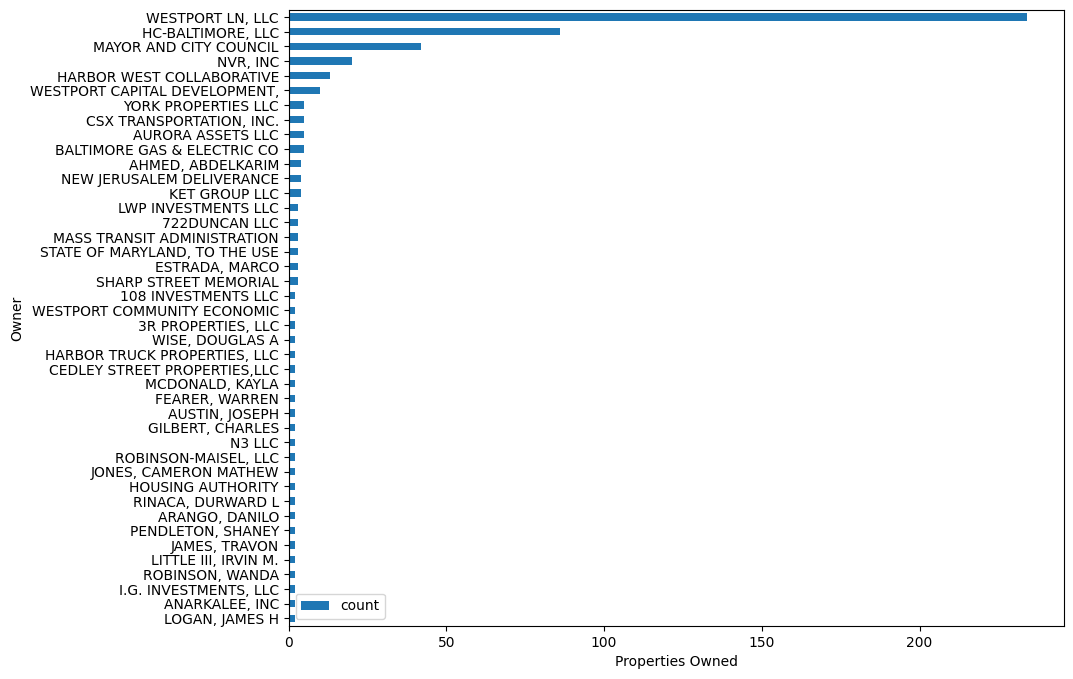

In [13]:
tranche_data = filter_by_owners_count(data)['OWNER_1'].value_counts().reset_index().set_index('OWNER_1')

combine_duplicates(tranche_data, { 
    "HC-BALTIMORE, LLC": ["HC-BALTIMORE, LLC", "HC-BALTIMORE LLC", "HC BALTIMORE, LLC"],
    "MAYOR AND CITY COUNCIL": ["MAYOR AND CITY COUNCIL OF", "MAYOR AND CITY COUNCIL"],
    "HARBOR WEST COLLABORATIVE": ["HARBOR WEST COLLABORATIVE", "HARBOR WEST COLLABORTIVE"],
    "NVR, INC": ["NVR, INC", "NVR, INC."],
    "BALTIMORE GAS & ELECTRIC CO": ["BALTIMORE GAS & ELECTRIC CO", "BALTO. GAS &ELECTRIC CO"]
}).sort_values(by=["count"]).plot(kind='barh', figsize=(10, 8), xlabel='Properties Owned', ylabel='Owner')

## The questions 
with the ownership and TIF data, I have some questions, even if I won't get to explore all/any of them:
- Who is receiving these grants funded through [Affordable Housing Tax Increment Financing](https://www.baltimorecity.gov/dhcd/our-work/affordable-housing/tax-increment-funding)? 
  - How many grants are being given out? What’s the multiplicity of the grant received per recipient.
  - Who bought properties in 23/24/25, around the time the legislation into law (December 2024)
  - Did they sell? How much did they sell for?
- How many properties/parcels do private equity own? 
  - Who are private equity owners?
- What public infrastructure programs are funded by these grants? / Are there any public infrastructure programs being funded by these grants?
- Is there market data available on the properties?
  - Are any of the rehabs on the market?
    - How much are the properties selling/renting for? The people who can afford to rehab a vacant even with the TIF cash injection still have to be pretty flush with cash.
  - How the housing prices of rehabbed homes in VRPG areas compare to property values of the areas they are in?
- Are we seeing affordable homeownership opportunities come from the TIF?

## Dictionary
- **VRPG**: [Vacancy Reducation Priority Geographies](https://app.powerbigov.us/view?r=eyJrIjoiY2YwMWNlZTItMjFkYy00OTZiLThjMGEtNWM4YzZhNDViMzJjIiwidCI6IjMxMmNiMTI2LWM2YWUtNGZjMi04MDBkLTMxOGU2NzljZTZjNyJ9), a term originating from Baltimore City’s Framework for Community Development "which designate specific areas as targets for intensive effort to eliminate
vacant properties."
- **BVRI**: [Baltimore Vacants Reinvestment Initiative](https://dhcd.maryland.gov/Reinvest-Baltimore/Pages/BVRI.aspx), offers grants and loans to Baltimore City, Maryland Stadium Authority, and community development organizations (CDOs) to demo, renovate, or aggregate vacant lots for housing, mixed-use projects, and greenspaces.
- **VRPA**: Violence Reduction Priority Areas
- **MCC**: Mayor and City Council (MCC) owned lots
- **CDC**: Community development corporations (CDCs) 